# Analysis of RPKM Tables

In [99]:
import os
import numpy as np
import pandas as pd
import json

import mygene

import matplotlib.pyplot as plt
import plotly.express as px


rpkm = r"../rpkm_values/rpkm_combined.txt"
healthy = r"../rpkm_values/rpkm_healthy/rpkm_values_healthy.txt"
t2d = r"../rpkm_values/rpkm_t2d/rpkm_values_t2d.txt"

In [100]:
df_combined = pd.read_csv(rpkm, sep='\t')
df_healthy = pd.read_csv(healthy, sep='\t')
df_t2d = pd.read_csv(t2d, sep='\t')

In [101]:
print(len(df_combined.columns))
print(len(df_healthy.columns))
print(len(df_t2d.columns))

142
97
45


In [102]:
# Transpose the RPKM dataframe so rows become samples
df = df_combined.T

# Now determine sample labels
healthy_samples = set(df_healthy.columns)
t2d_samples = set(df_t2d.columns)

# Assign condition based on sample name
df['condition'] = ['healthy' if sample in healthy_samples else 't2d' for sample in df.index]
# Add donor name column
df['donor'] = df.index.str.split('_').str[0]



In [103]:
t2d_samples

{'HP1504101T2D_B6.bam',
 'HP1504101T2D_C18.bam',
 'HP1504101T2D_D9.bam',
 'HP1504101T2D_E15.bam',
 'HP1504101T2D_E16.bam',
 'HP1504101T2D_E24.bam',
 'HP1504101T2D_H23.bam',
 'HP1504101T2D_H6.bam',
 'HP1504101T2D_N10.bam',
 'HP1504101T2D_O12.bam',
 'HP1508501T2D_B16.bam',
 'HP1508501T2D_I8.bam',
 'HP1508501T2D_J6.bam',
 'HP1526901T2D_A1.bam',
 'HP1526901T2D_A14.bam',
 'HP1526901T2D_A19.bam',
 'HP1526901T2D_A2.bam',
 'HP1526901T2D_A5.bam',
 'HP1526901T2D_B1.bam',
 'HP1526901T2D_E11.bam',
 'HP1526901T2D_E2.bam',
 'HP1526901T2D_G17.bam',
 'HP1526901T2D_G21.bam',
 'HP1526901T2D_G4.bam',
 'HP1526901T2D_H10.bam',
 'HP1526901T2D_H20.bam',
 'HP1526901T2D_H22.bam',
 'HP1526901T2D_H24.bam',
 'HP1526901T2D_H4.bam',
 'HP1526901T2D_I13.bam',
 'HP1526901T2D_I3.bam',
 'HP1526901T2D_J21.bam',
 'HP1526901T2D_K20.bam',
 'HP1526901T2D_K23.bam',
 'HP1526901T2D_K3.bam',
 'HP1526901T2D_K7.bam',
 'HP1526901T2D_L1.bam',
 'HP1526901T2D_L5.bam',
 'HP1526901T2D_M15.bam',
 'HP1526901T2D_N1.bam',
 'HP1526901T2D_N12

In [89]:
# Create a dictionary mapping ensembl_ids to gene symbols

ensembl_ids = list(df.drop(columns=['condition', 'donor']).columns)

query_cache_file = "query_result.json"

# Batch query: return gene symbol for each Ensembl ID (This will take 2 minutes)
if os.path.exists(query_cache_file):
    with open(query_cache_file, "r") as f:
        query_result = json.load(f)
    print(f"Loaded cached MyGene.info results from {query_cache_file}")
else:
    mg = mygene.MyGeneInfo()
    query_result = mg.querymany(ensembl_ids, scopes='ensembl.gene', fields='symbol', species='human')

    # Save for future reuse
    with open(query_cache_file, "w") as f:
        json.dump(query_result, f)
    print(f"Fetched MyGene.info results and cached to {query_cache_file}")

# Build a mapping: ENSG ID → gene symbol
ensembl_to_symbol = {
    item['query']: item.get('symbol', item['query'])  # fallback to ENSG ID if no symbol found
    for item in query_result
}

no_hit_count = sum(1 for item in query_result if item.get('notfound', False))
print(f"{len(ensembl_to_symbol) - no_hit_count} of {len(ensembl_ids)} ensembl to symbol mapped")

Loaded cached MyGene.info results from query_result.json
61474 of 62710 ensembl to symbol mapped


In [90]:
# Rename columns from ensembl ids to gene ids
df.rename(columns=ensembl_to_symbol, inplace=True)
gene_ids = list(df.drop(columns=['condition', 'donor']).columns)
len(gene_ids)

62710

## Trimming Low-Expression Genes
(represented in fewer than 5 cells)

In [91]:
df_filtered = df.drop(columns=['condition', 'donor'])

In [92]:
df_filtered = df_filtered.loc[:, (df_filtered > 0).sum(axis=0) > 5]

In [93]:
df_filtered.shape

(142, 16361)

In [94]:
df_filtered = pd.concat([df[['condition', 'donor']], df_filtered], axis=1)

## t-SNE (t-distributed Stochastic Neighbor Embedding)
16361 genes

In [71]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [73]:
# Drop the label column to get expression matrix
X = df_filtered.drop(columns=['condition', 'donor'])
X_log = np.log2(X + 1)

In [82]:
# PCA
X_pca = PCA(n_components=30).fit_transform(X_log)
# Run t-SNE
X_tsne = TSNE(n_components=2, random_state=24).fit_transform(X_pca)

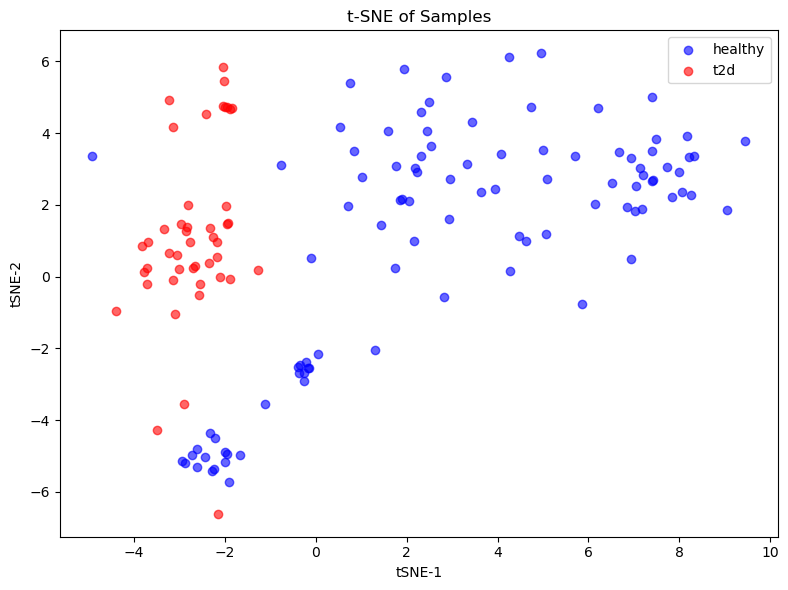

In [83]:
# Plot
plt.figure(figsize=(8, 6))
colors = {'healthy': 'blue', 't2d': 'red'}
for cond in df_filtered['condition'].unique():
    ix = df_filtered['condition'] == cond
    plt.scatter(X_tsne[ix, 0], X_tsne[ix, 1], label=cond, c=colors[cond], alpha=0.6)

plt.title('t-SNE of Samples')
plt.xlabel('tSNE-1')
plt.ylabel('tSNE-2')
plt.legend()
plt.tight_layout()
plt.show()

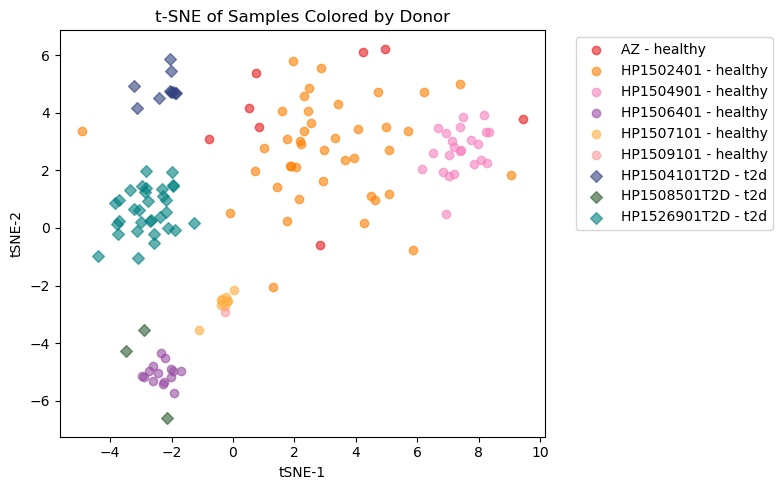

In [84]:
# Plot with donor-specific colors
plt.figure(figsize=(8, 5))
markers = {'healthy': 'o', 't2d': 'D'} 
colors = [
    "#e41a1c",  # warm - red
    "#ff7f00",  # warm - orange
    "#f781bf",  # warm - pink
    "#984ea3",  # warm - purple
    "#ffae42",  # warm - goldenrod
    "#fb9a99",  # warm - salmon

    "#30417f",  # cool - blue
    "#2b592e",  # cool - green
    "#008080"   # cool - teal
]
donors = df_filtered['donor'].unique()
donor_colors = dict(zip(donors, colors))

for donor in df_filtered['donor'].unique():
    ix = df_filtered['donor'].values == donor
    condition = df_filtered[df_filtered['donor'] == donor]['condition'].unique()[0]
    
    plt.scatter(
        X_tsne[ix, 0], 
        X_tsne[ix, 1], 
        label=f"{donor} - {condition}", 
        color=donor_colors[donor],
        marker=markers.get(condition, 'o'), 
        alpha=0.6
    )

plt.title('t-SNE of Samples Colored by Donor')
plt.xlabel('tSNE-1')
plt.ylabel('tSNE-2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Top 50 Most Variable Genes
Figure 4B-left

In [79]:
top_var_genes = X_log.var(axis=0).sort_values(ascending=False).head(50).index
X_top = X[top_var_genes]
X_top.shape

(142, 50)

In [80]:
X_pca = PCA(n_components=30).fit_transform(X_log)
tsne = TSNE(n_components=2, perplexity=30, random_state=23)
X_tsne = tsne.fit_transform(X_pca)

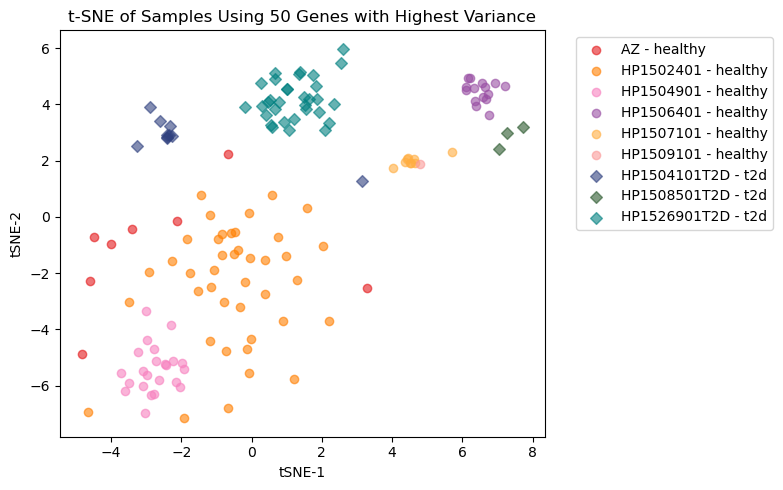

In [81]:
# Plot with donor-specific colors
plt.figure(figsize=(8, 5))
markers = {'healthy': 'o', 't2d': 'D'} 
colors = [
    "#e41a1c",  # warm - red
    "#ff7f00",  # warm - orange
    "#f781bf",  # warm - pink
    "#984ea3",  # warm - purple
    "#ffae42",  # warm - goldenrod
    "#fb9a99",  # warm - salmon

    "#30417f",  # cool - blue
    "#2b592e",  # cool - green
    "#008080"   # cool - teal
]
donors = df_filtered['donor'].unique()
donor_colors = dict(zip(donors, colors))

for donor in df_filtered['donor'].unique():
    ix = df_filtered['donor'].values == donor
    condition = df_filtered[df_filtered['donor'] == donor]['condition'].unique()[0]
    
    plt.scatter(
        X_tsne[ix, 0], 
        X_tsne[ix, 1], 
        label=f"{donor} - {condition}", 
        color=donor_colors[donor],
        marker=markers.get(condition, 'o'), 
        alpha=0.6
    )

plt.title('t-SNE of Samples Using 50 Genes with Highest Variance')
plt.xlabel('tSNE-1')
plt.ylabel('tSNE-2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Feature Selection

In [58]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Extract X (features) and y (labels)
X = df_filtered.drop(columns=['condition', 'donor'])
X_log = np.log2(X + 1)
y = df_filtered['condition']

# Encode 'healthy' = 0, 't2d' = 1
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [66]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_log, y_encoded, stratify=y_encoded, test_size=0.3, random_state=23)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
#clf = LogisticRegression(penalty='l2', solver='saga', max_iter=1000, random_state=23)
clf = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=23) # l1 or l2 penalty
#clf = LogisticRegression(penalty=None, max_iter=1000, random_state=23)

clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000, penalty='l1', random_state=23,
                   solver='liblinear')

In [67]:
feature_importance = pd.Series(clf.coef_[0], index=X_train.columns)
top_genes = feature_importance.abs().sort_values(ascending=False).head(15)
top_genes

MICOS10P3    0.409512
EDN3         0.304559
MTCYBP18     0.231360
FXYD2        0.208618
MAST1        0.205721
HLA-U        0.192717
TIMM29       0.163810
ZFP36        0.146770
RPS4Y1       0.135435
RNF135       0.132582
SLC16A9      0.110282
IGFBP7       0.087286
RBP4         0.086843
URB1-AS1     0.084143
RNU4ATAC     0.082600
dtype: float64

In [69]:
# These are genes commonly-linked to T2D
t2d_genes = [
    "TCF7L2", "CDKAL1", "KCNJ11", "PPARG", "HHEX", "SLC30A8", "IGF2BP2", "CDKN2A", "CDKN2B",
    "FTO", "MC4R", "CDC123", "PHF2", "SLC16A11", "ANK1", "NOTCH2", "JAZF1", "WFS1", "GLIS3",
    "GCK", "GCKR", "HNF1A", "HNF4A", "PAX5", "TET1", "CHL1", "GLRA1", "IAPP", "CAPN10", "ABCC8",
    "GCGR", "ADAMTS9", "ADIPOQ", "IRS1", "SREBF1", "EXT2", "MEF2C", "TMEM161B", "CEP120", 
    "PRDM6", "STEAP1", "ZNF804B", "ZNRF3", "PRIM1", "IRF2BPL", "LRRC74A"
]

set(top_genes.index) & set(t2d_genes)

set()